# <span style="color:purple; font-weight:bold; text-decoration:underline;"> East Asian Oxidant Climatologies

### <span style='color:purple'> Imports

In [4]:
# Third-party imports
import xarray as xr

# Custom utilities
import utils
from utils.load_variable import load_variables_for_all_years

### <span style='color:purple'> Opening Regional and Variable DataArrays

In [2]:
NPAC = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/NPAC_mask.nc')    
East_Asia = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/East_Asia/East_Asia_Mask.nc')
area = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')

### <span style='color:purple'> Derive Air Number Density with IGL (PMID, Temp, kB)

In [10]:
kB = 1.380649e-23  # J/K

PMID_1970 = xr.open_dataset('/glade/work/jzweifel/data_1970/h2_concat_1970.nc')['PMID']
T_1970    = xr.open_dataset('/glade/work/jzweifel/data_1970/h2_concat_1970.nc')['T']

air_number_density_1970 = PMID_1970 / (kB * T_1970) / 1e6
air_number_density_1970.attrs["units"] = "molecules cm^-3"

### <span style='color:purple'> Convert Mol/Mol x→ Molecules/cm3

In [4]:
O3_raw = xr.open_dataset('/glade/work/jzweifel/data_1970/h5_concat_1970.nc')['O3']
OH_raw = xr.open_dataset('/glade/work/jzweifel/data_1970/h5_concat_1970.nc')['OH']
H2O2_raw = xr.open_dataset('/glade/work/jzweifel/data_1970/h1_concat_1970.nc')['H2O2']

O3_raw = load_variables_for_all_years('h5', 'O3')

O3_1970 = ((O3_raw * air_number_density_1970).where(East_Asia).groupby('time.month').mean(dim='time').roll(month=-1))

OH_1970 = ((OH_raw * air_number_density_1970).where(East_Asia).groupby('time.month').mean(dim='time').roll(month=-1))

H2O2_1970 = ((H2O2_raw * air_number_density_1970).where(East_Asia).groupby('time.month').mean(dim='time').roll(month=-1))

### <span style='color:purple'> Plotting 1970 East Asian Oxidant Seasonalities

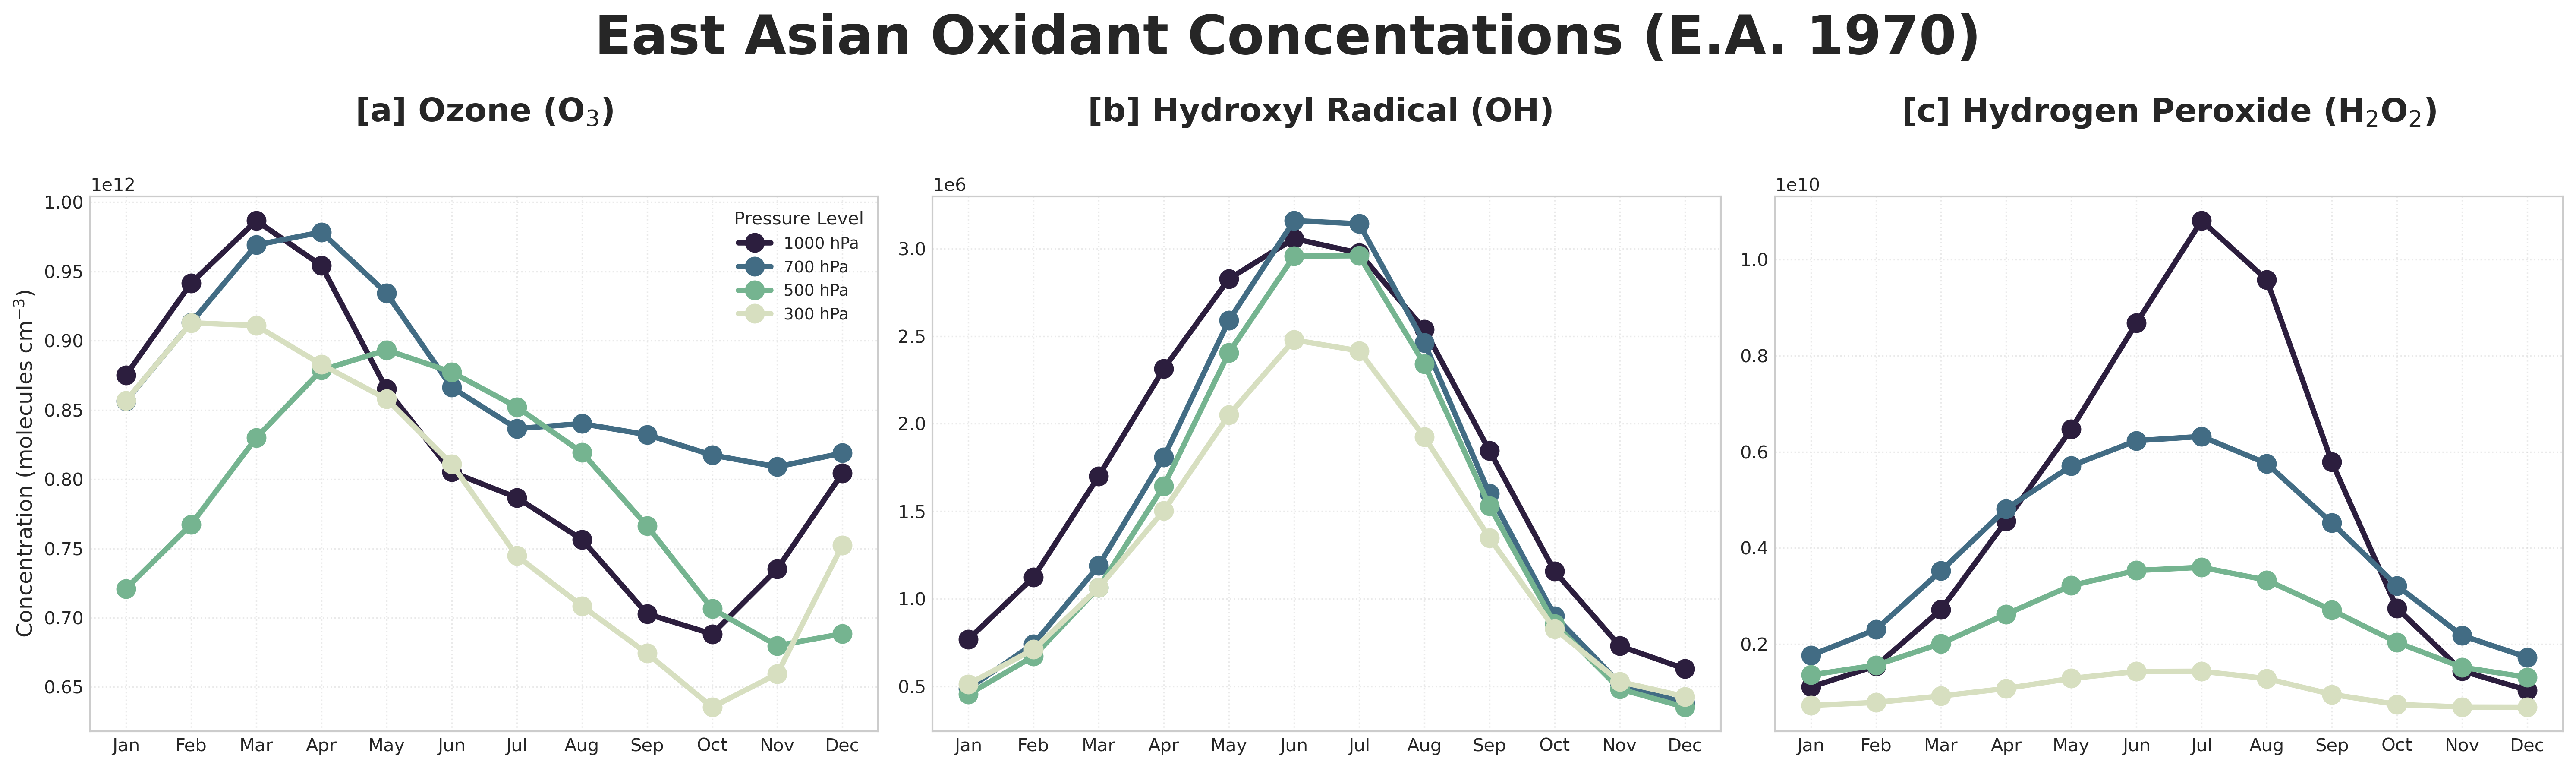

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import calendar
import seaborn as sns
import numpy as np

import calendar
months = calendar.month_abbr[1:]

# ---------------------------------------------------------
# Discrete cubehelix colors for pressure levels
# ---------------------------------------------------------
levels = [1000, 700, 500, 300]

level_colors_list = sns.cubehelix_palette(n_colors=len(levels), start=.5, rot=-.75, reverse=True)

# Map: 1000 → color0, 700 → color1, ..., 300 → color3
level_colors = {lev: color for lev, color in zip(levels, level_colors_list)}

# ---------------------------------------------------------
# Global style
# ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "legend.frameon": False,
    "lines.linewidth": 2,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

# ---------------------------------------------------------
# Inputs
# ---------------------------------------------------------
titles = [
    "[a] Ozone (O$_{3}$)",
    "[b] Hydroxyl Radical (OH) ",
    "[c] Hydrogen Peroxide (H$_{2}$O$_{2}$)"
]

data_arrays = [O3_1970, OH_1970, H2O2_1970]

# ---------------------------------------------------------
# Figure and axes
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), dpi=300, sharex=True)

# ---------------------------------------------------------
# O3 panel
# ---------------------------------------------------------
ax = axs[0]
da = O3_1970

ax.plot(months, da.sel(lev=1000, method='nearest').mean(['lat', 'lon']), color=level_colors[1000], marker='o', label="1000 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=700, method='nearest').mean(['lat', 'lon']), color=level_colors[700], marker='o', label="700 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=500, method='nearest').mean(['lat', 'lon']), color=level_colors[500], marker='o', label="500 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=300, method='nearest').mean(['lat', 'lon']), color=level_colors[300], marker='o', label="300 hPa", linewidth=3, markersize=10)

ax.set_title(titles[0], fontsize=18, y=1.12)
ax.set_ylabel("Concentration (molecules cm$^{-3}$)", fontsize=12)

# ---------------------------------------------------------
# OH panel
# ---------------------------------------------------------
ax = axs[1]
da = OH_1970

ax.plot(months, da.sel(lev=1000, method='nearest').mean(['lat','lon']),color=level_colors[1000], marker='o', label="1000 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=700, method='nearest').mean(['lat','lon']), color=level_colors[700], marker='o', label="700 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=500, method='nearest').mean(['lat','lon']), color=level_colors[500], marker='o', label="500 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=300, method='nearest').mean(['lat','lon']), color=level_colors[300], marker='o', label="300 hPa", linewidth=3, markersize=10)

ax.set_title(titles[1], fontsize=18, y=1.12)

# ---------------------------------------------------------
# H2O2 panel
# ---------------------------------------------------------
ax = axs[2]
da = H2O2_1970

ax.plot(months, da.sel(lev=1000, method='nearest').mean(['lat','lon']), color=level_colors[1000], marker='o', label="1000 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=700, method='nearest').mean(['lat','lon']), color=level_colors[700], marker='o', label="700 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=500, method='nearest').mean(['lat','lon']), color=level_colors[500], marker='o', label="500 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=300, method='nearest').mean(['lat','lon']),color=level_colors[300], marker='o', label="300 hPa", linewidth=3, markersize=10)

ax.set_title(titles[2], fontsize=18, y=1.12)

# ---------------------------------------------------------
# Legend (one unified)
# ---------------------------------------------------------
axs[0].legend(title="Pressure Level", loc="upper right", fontsize=9)

fig.suptitle('East Asian Oxidant Concentations (E.A. 1970)', fontsize=30, weight='bold')
fig.tight_layout()
plt.savefig('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/saved_figures_pngs/Figure_07.png')

plt.show()